### **Imports pour les Exercices**

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time

from scipy import signal
from scipy.io.wavfile import read, write
import sounddevice as sd

from skimage import exposure, color, filters, measure, morphology
from scipy.ndimage import convolve
from scipy.signal import convolve2d, medfilt2d

### **Ex 1** : Traitement Image `trees.png`

Dimensions Image Originale : (258, 350, 3)
Type de l'image Originale : float32
Min et Max de l'image Originale : 0.0, 1.0
Dimensions Image Niveau de Gris : (258, 350)
Type de l'image Niveau de Gris : float64
Min et Max de l'image Niveau de Gris : 0.0, 0.9999999403953552


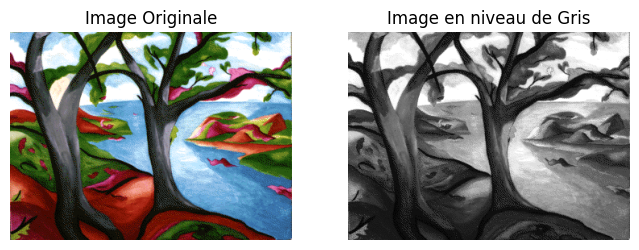

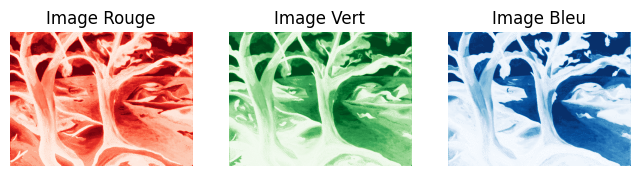

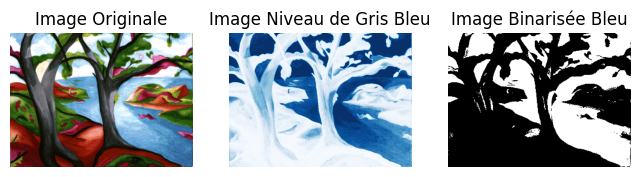

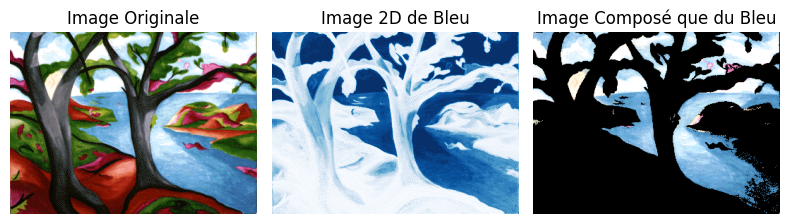

In [130]:
TreesImg = "C:/Users/pc/OneDrive - EPHEC asbl/Bureau/Cours/Cours 3ème/Traitements-des-signaux/Questions-Type-Exam/Exam-Pratique/Fichiers_pour_examen_Version_2022/trees.png"
trees = plt.imread(TreesImg)

print(f"Dimensions Image Originale : {trees.shape}")
print(f"Type de l'image Originale : {trees.dtype}")
print(f"Min et Max de l'image Originale : {trees.min()}, {trees.max()}")

if trees.shape[2] == 3 :
    trees_gray = color.rgb2gray(trees)
    trees_gray = trees_gray.astype('float64')
else :
    trees_gray = trees.copy()

print(f"Dimensions Image Niveau de Gris : {trees_gray.shape}")
print(f"Type de l'image Niveau de Gris : {trees_gray.dtype}")
print(f"Min et Max de l'image Niveau de Gris : {trees_gray.min()}, {trees_gray.max()}")

# Composantes RGB
trees_red = trees[:, :, 0]
trees_green = trees[:, :, 1]
trees_blue = trees[:, :, 2]

# Calcul du seuil 
threshold = filters.threshold_otsu(trees_blue)
# threshold = 0.2

trees_bin_blue = trees_blue > threshold

masque = trees[:, :, 2] > 0.7

trees_blue_lonely = np.zeros_like(trees)
trees_blue_lonely[masque] = trees[masque]

# --------------- Images Originale et en Niveau de Gris ---------------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(trees)
axes[0].set_title("Image Originale")
axes[0].axis("off")

axes[1].imshow(trees_gray, cmap='gray')
axes[1].set_title("Image en niveau de Gris")
axes[1].axis("off")

# --------------- Images en Composantes RGB ---------------------------------
fig, axes = plt.subplots(1, 3, figsize=(8, 4))

axes[0].imshow(trees_red, cmap='Reds')
axes[0].set_title("Image Rouge")
axes[0].axis("off")

axes[1].imshow(trees_green, cmap='Greens')
axes[1].set_title("Image Vert")
axes[1].axis("off")

axes[2].imshow(trees_blue, cmap='Blues')
axes[2].set_title("Image Bleu")
axes[2].axis("off")
# --------------- Image Binaire qui met le Bleu en évidence ---------------------------------
fig, axes = plt.subplots(1, 3, figsize=(8, 4))

axes[0].imshow(trees)
axes[0].set_title("Image Originale")
axes[0].axis("off")

axes[1].imshow(trees_blue, cmap='Blues')
axes[1].set_title("Image Niveau de Gris Bleu")
axes[1].axis("off")

axes[2].imshow(trees_bin_blue, cmap='gray')
axes[2].set_title("Image Binarisée Bleu")
axes[2].axis("off")

# --------------- Image en Noir et Blanc avec le Bleu qui ressort -------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(8, 4))

axes[0].imshow(trees)
axes[0].set_title("Image Originale")
axes[0].axis("off")

axes[1].imshow(trees_blue, cmap='Blues')
axes[1].set_title("Image 2D de Bleu")
axes[1].axis("off")

axes[2].imshow(trees_blue_lonely)
axes[2].set_title("Image Composé que du Bleu")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### **EX 2** : Signaux 1D Son avec Battement

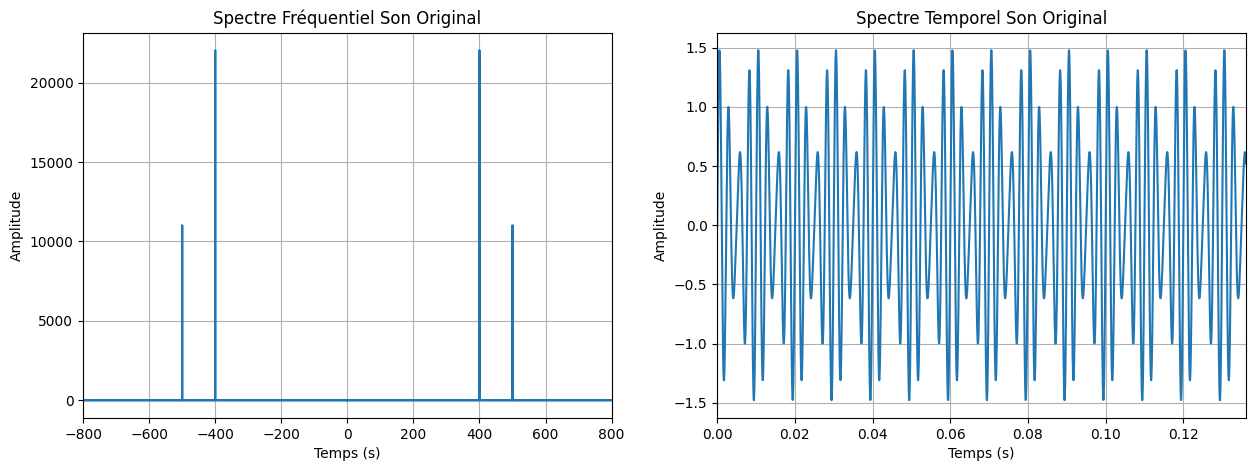

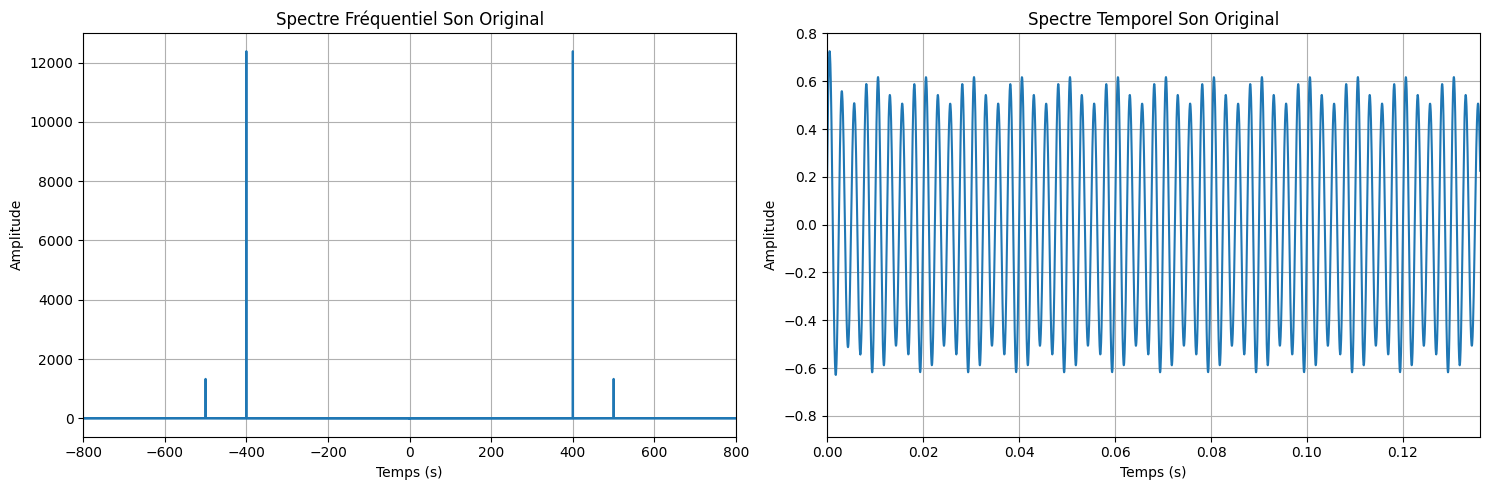

In [110]:
# Création variables
Fe = 22050
Te = 1/Fe
duration = 2

amp_400 = 1
amp_500 = 0.5

f_signal_400 = 400
f_signal_500 = 500

# Création du signal sonore
t = np.arange(0, duration, Te)
s1 = amp_400 * np.sin(2 * np.pi * f_signal_400 * t)
s2 = amp_500 * np.sin(2 * np.pi * f_signal_500 * t)

s_final = s1 + s2

f = np.fft.fftfreq(len(t), Te)
TF = np.fft.fft(s_final)

# ------------------------------------------------------------

fc = 410
wc = fc / (Fe/2)
b, a = signal.butter(5, wc, btype='low')

s_filtred = signal.filtfilt(b, a, s_final)

f_filtred = np.fft.fftfreq(len(t), Te)
TF_filtred = np.fft.fft(s_filtred)

# -------------- Affichage Son de base ------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(f, np.abs(TF))
axes[0].set_title(f"Spectre Fréquentiel Son Original")
axes[0].set_xlabel("Temps (s)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)
axes[0].set_xlim([-800, 800])

axes[1].plot(t, s_final)
axes[1].set_title(f"Spectre Temporel Son Original")
axes[1].set_xlabel("Temps (s)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True)
axes[1].set_xlim([0, Te*3000])

# -------------- Affichage Son Filtré ------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(f_filtred, np.abs(TF_filtred))
axes[0].set_title(f"Spectre Fréquentiel Son Original")
axes[0].set_xlabel("Temps (s)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)
axes[0].set_xlim([-800, 800])

axes[1].plot(t, s_filtred)
axes[1].set_title(f"Spectre Temporel Son Original")
axes[1].set_xlabel("Temps (s)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True)
axes[1].set_xlim([0, Te*3000])

# ------------------------------------------------------------
plt.tight_layout()
plt.show()

# sd.play(s_final, Fe)
# sd.play(s_filtred, Fe)

### **EX 3** : Traitement image `blood.png`

Dimensions image Original : (345, 460, 3)
Type image Original : float32
Dimensions image BnW : (345, 460)
Type image BnW : float64
Region : 1645.0 Label : 1
Region : 914.0 Label : 2
Region : 1419.0 Label : 3
Region : 1516.0 Label : 4
Region : 1075.0 Label : 5
Region : 1184.0 Label : 6
Region : 1000.0 Label : 7
Region : 1149.0 Label : 8
Region : 970.0 Label : 9
Region : 1328.0 Label : 10
Region : 141.0 Label : 11
Region : 1786.0 Label : 12
Region : 987.0 Label : 13
Nombres de regions : 13
min_cell = 141.0
Taille moyenne d'une cellule : 1162.62


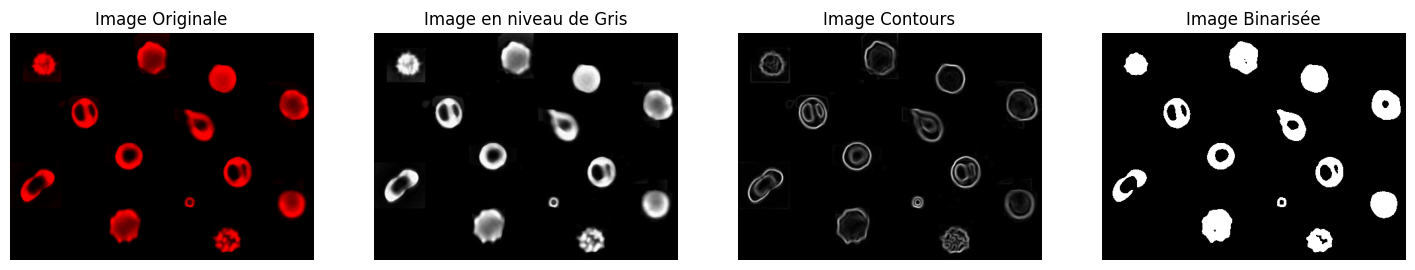

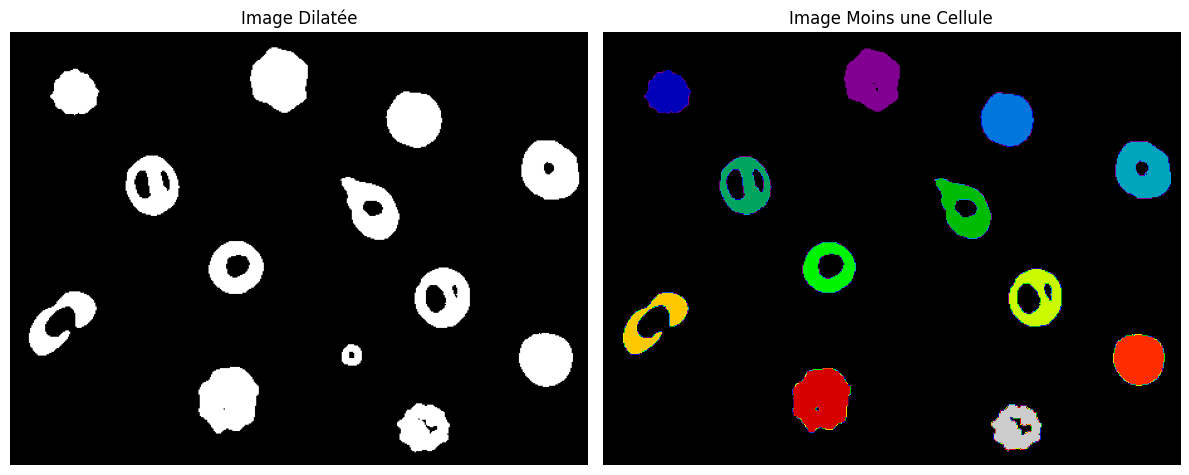

In [167]:
BloodImg = "C:/Users/pc/OneDrive - EPHEC asbl/Bureau/Cours/Cours 3ème/Traitements-des-signaux/Questions-Type-Exam/Exam-Pratique/Fichiers_pour_examen_Version_2022/blood.png"
blood = plt.imread(BloodImg)

print(f"Dimensions image Original : {blood.shape}\n"
      f"Type image Original : {blood.dtype}")

if blood.shape[2] == 3:
    blood_gray = color.rgb2gray(blood)
    blood_gray = blood_gray.astype('float64')
else :
    blood_gray = blood.copy()

print(f"Dimensions image BnW : {blood_gray.shape}\n"
      f"Type image BnW : {blood_gray.dtype}")

# ---------------- Filtered ----------------
blood_sobel = filters.sobel(blood_gray, mode='reflect')

# ---------------- Binarisée ----------------
threshold = filters.threshold_otsu(blood_gray)

blood_bin = blood_gray > threshold

# ------------- Dilatation ------------------
# h = [[1, 1, 1],
#      [1, 0, 1],
#      [1, 1, 1]]
blood_dilated = morphology.dilation(blood_bin, mode='reflect')
# blood_dilated = convolve2d(blood_bin, h, mode='same', boundary='symm')

# ----------- Labelisation ------------------
labels, num_of_labels = measure.label(blood_bin, return_num=True)

regions = measure.regionprops(labels)

for region in regions:
    print(f"Region : {region.area} Label : {region.label}")

# ------------ Nombres de Régions --------------------------
print(f"Nombres de regions : {len(regions)}")

# --------------- Enlever une cellule ----------------
min_cell_area = 2000
min_labels = None

for region in regions:
    if region.area < min_cell_area :
        min_cell_area = region.area
        min_labels = region.label

print(f"min_cell = {min_cell_area}")
blood_bin2 = morphology.remove_small_objects(blood_bin, min_size=min_cell_area + 1)
blood_labeled = measure.label(blood_bin2)

# ------------- Taille moyenne d'une Cellule --------------------
count = 0
sum_area = 0
for region in regions:
    sum_area += region.area
    count += 1

blood_cell_area_mean = sum_area / count
print(f"Taille moyenne d'une cellule : {blood_cell_area_mean:.2f}")

# ----------------- Image Original, BnW et Sobel ----------------------
fig, axes = plt.subplots(1, 4, figsize=(18, 10))

axes[0].imshow(blood)
axes[0].set_title("Image Originale")
axes[0].axis("off")

axes[1].imshow(blood_gray, cmap='gray')
axes[1].set_title("Image en niveau de Gris")
axes[1].axis("off")

axes[2].imshow(blood_sobel, cmap='gray')
axes[2].set_title("Image Contours")
axes[2].axis("off")

axes[3].imshow(blood_bin, cmap='gray')
axes[3].set_title("Image Binarisée")
axes[3].axis("off")

# ----------------------- Image Dilatée et Sans une cellule-------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

axes[0].imshow(blood_dilated, cmap='gray')
axes[0].set_title("Image Dilatée")
axes[0].axis("off")

axes[1].imshow(blood_labeled, cmap='nipy_spectral')
axes[1].set_title("Image Moins une Cellule")
axes[1].axis("off")

# ---------------------------------------------------------------------
plt.tight_layout()
plt.show()


### **EX 4** : Traitement image `spots_noisy.png`

Dimensions image Original : (410, 597)
Type image Original : float32
Dimensions image BnW : (410, 597)
Type image BnW : float64
Region : 1.0 Label : 1
Region : 1.0 Label : 2
Region : 2155.0 Label : 3
Region : 3336.0 Label : 4
Region : 1512.0 Label : 5
Region : 2393.0 Label : 6
Region : 3736.0 Label : 7
Region : 4560.0 Label : 8
Region : 3507.0 Label : 9
Region : 3026.0 Label : 10
Region : 3015.0 Label : 11
Region : 5660.0 Label : 12
Region : 2820.0 Label : 13
Region : 3832.0 Label : 14
Region : 5407.0 Label : 15
Region : 1.0 Label : 16
Region : 1.0 Label : 17
Nombre d'ellipse : 13
Taille moyenne area d'une ellispe : 3458.3846153846152


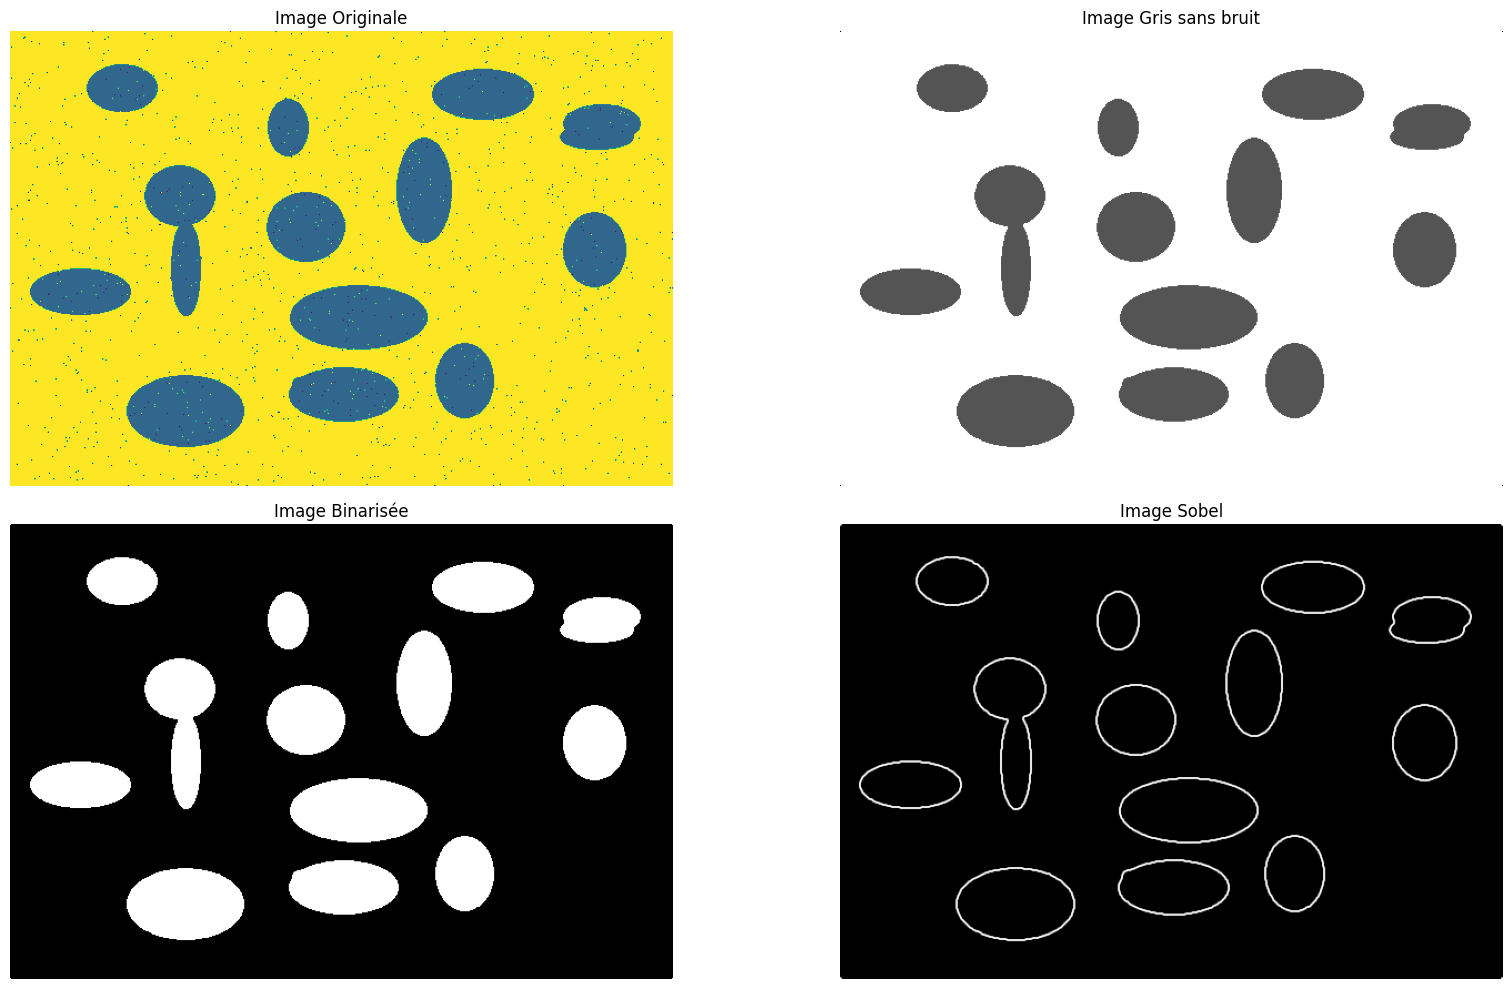

In [ ]:
spots_noisy_Img = "C:/Users/pc/OneDrive - EPHEC asbl/Bureau/Cours/Cours 3ème/Traitements-des-signaux/Questions-Type-Exam/Exam-Pratique/Fichiers_pour_examen_Version_2022/spots_noisy.png"
spots_noisy = plt.imread(spots_noisy_Img)

print(f"Dimensions image Original : {spots_noisy.shape}\n"
      f"Type image Original : {spots_noisy.dtype}")

if len(spots_noisy.shape) == 3:
    spots_noisy_gray = color.rgb2gray(spots_noisy)
    spots_noisy_gray = spots_noisy_gray.astype('float64')
else :
    spots_noisy_gray = spots_noisy.copy()
    spots_noisy_gray = spots_noisy_gray.astype('float64')

print(f"Dimensions image BnW : {spots_noisy_gray.shape}\n"
      f"Type image BnW : {spots_noisy_gray.dtype}")

# ------------------ Enlever le Bruit Filtre Médian ---------------------
spots_noisy_clean = signal.medfilt2d(spots_noisy_gray)

# --------------------------- Binarisation ------------------------------
# threshold = filters.threshold_otsu(spots_noisy)
threshold = 0.9

spots_noisy_bin = spots_noisy_clean < threshold

# ------------------------ Labelisation compter le nombre d'ellipse --------------------------
labels1, number_of_labels1 = measure.label(spots_noisy_bin, return_num=True)

regions1 = measure.regionprops(labels1)

number_of_ellipse = 0
total_regions_area = 0

for region in regions1:
    print(f"Region : {region.area} Label : {region.label}")
    if region.area > 10:
        number_of_ellipse += 1
        total_regions_area += region.area

area_mean = total_regions_area / number_of_ellipse

print(f"Nombre d'ellipse : {number_of_ellipse}\n"
      f"Taille moyenne area d'une ellispe : {area_mean}")


# ----------------------- Detection de contour Sobel -------------------------
spots_noisy_bin_sobel = filters.sobel(spots_noisy_bin, mode='reflect')

# ---------------- Image Original et Binarisée -------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

axes[0][0].imshow(spots_noisy)
axes[0][0].set_title("Image Originale")
axes[0][0].axis("off")

axes[0][1].imshow(spots_noisy_clean, cmap='gray')
axes[0][1].set_title("Image Gris sans bruit")
axes[0][1].axis("off")

axes[1][0].imshow(spots_noisy_bin, cmap='gray')
axes[1][0].set_title("Image Binarisée")
axes[1][0].axis("off")

axes[1][1].imshow(spots_noisy_bin_sobel, cmap='gray')
axes[1][1].set_title("Image Sobel")
axes[1][1].axis("off")

plt.tight_layout()
plt.show()